# Reproducing every number in the manuscript

This notebook recomputes, step by step, **every quantitative result** of the
manuscript on a single CS1 class that adopted a four-layer AI-supported
practice ecosystem, starting from the de-identified files in `data/`. Each
result is followed by `check(...)`, which compares the value computed here
with the value printed in the manuscript and stops the notebook if they
disagree. A **📄 In the manuscript** note says where each number appears.

**Inputs** (all in `data/`, all de-identified — see `README.md`):

| file | content | used in |
|---|---|---|
| `class_series.csv` | final-grade counts per class of the course, 2009–2026 (840 classes; no student-level data, no class codes) | Parts 1 and 7 |
| `profile.csv` | profile questionnaire (identification optional, removed) | Part 2 |
| `perception.csv` | 20-item Likert perception questionnaire (identification optional, removed), analysed class and the two comparison classes | Parts 3, 4 and 7 |
| `exams.csv` | exam and mock-exam scores per student, random IDs | Parts 5 and 6 |
| `llm_usage.csv` | LLM provider usage exports before/after two grading runs | Part 5 |

**Labels.** *Analysed class* = the daytime class studied (2026.1, Campus 1,
label `B1` in `class_series.csv`). *Comparison classes* = the two evening
classes of Campus 2 that used Layers 1–3 with their own assessment design
(`C1`, `C2`). *Instructor* = the instructor of the analysed class, whose
earlier offerings are flagged `instructor_prior` in `class_series.csv`.
Campuses are pseudonymised as `1` and `2`.

**Conventions.** Failure rate = (F + O) / assessed, where F = failed on
performance and O = failed on absence. Exam scores are on a 0–100 scale
(two questions of 50 points). Likert items: 1 = strongly disagree … 5 =
strongly agree; Q01–Q17 are substantive, Q18–Q20 are validity checks.

In [1]:
# --- Setup --------------------------------------------------------------------
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory
from IPython.display import display

DATA = Path("data")
# In Colab (or anywhere the notebook runs without the repository), fetch the
# de-identified CSVs from the public repository first.
FILES = ["class_series.csv", "profile.csv", "perception.csv", "exams.csv", "llm_usage.csv",
         "exam1_llm_models.csv"]
if not all((DATA / f).exists() for f in FILES):
    import urllib.request
    RAW = "https://raw.githubusercontent.com/fzampirolli/cs1-ai-methodology-reproducibility/main/data/"
    DATA.mkdir(exist_ok=True)
    for f in FILES:
        urllib.request.urlretrieve(RAW + f, DATA / f)
    print("data/ downloaded from", RAW)
EXAM3 = Path("exam3")
if not (EXAM3 / "example_llm_output.txt").exists():
    import urllib.request
    EXAM3.mkdir(exist_ok=True)
    for f in ["prompt_exam3.txt", "statement_variation1.txt", "example_llm_output.txt"]:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/fzampirolli/cs1-ai-methodology-reproducibility/main/exam3/" + f,
            EXAM3 / f)
RNG = np.random.default_rng(20260923)   # one generator, used in a fixed order (Part 3)
NBOOT = 5000                             # bootstrap resamples

def check(name, got, expected, tol=0.005):
    "Compare a computed value with the manuscript's; stop loudly if they differ."
    ok = abs(float(got) - float(expected)) <= tol
    print(f"  [{'OK' if ok else 'XX'}] {name}: computed={got:.4g}  manuscript={expected}")
    assert ok, f"{name}: {got} != {expected} (tol {tol})"

pct = lambda k, n: 100 * k / n
series = pd.read_csv(DATA / "class_series.csv", dtype={"term": str, "campus": str})
series["year"] = series.term.str[:4].astype(int)
series["rate"] = series.n_failed / series.n_assessed
profile = pd.read_csv(DATA / "profile.csv")
perc = pd.read_csv(DATA / "perception.csv")
exams = pd.read_csv(DATA / "exams.csv")
usage = pd.read_csv(DATA / "llm_usage.csv", dtype={"run": str})

# Guard: no personal-data column may be present.
for name, df in [("class_series", series), ("profile", profile), ("perception", perc),
                 ("exams", exams), ("llm_usage", usage)]:
    bad = [c for c in df.columns if any(w in c.lower() for w in
           ("name", "mail", "login", "user", "key", "code", "enrol"))]
    assert not bad, (name, bad)
    print(f"{name:13s} {len(df):4d} rows, {df.shape[1]:2d} columns")

class_series   840 rows, 20 columns
profile         69 rows,  7 columns
perception      74 rows, 22 columns
exams           41 rows, 21 columns
llm_usage       20 rows,  4 columns


---
# Part 1 — The analysed class and its context

Failure data come from the institution's academic record, aggregated per
class. `on_schedule_term` marks, for each year, the term with the most
classes (the term in which the curriculum recommends the course).

In [2]:
t261 = series[series.term == "2026.1"]
print(f"2026.1: {len(t261)} classes, {t261.n_assessed.sum()} students assessed")
check("classes in 2026.1", len(t261), 40, 0)
check("students assessed in 2026.1", t261.n_assessed.sum(), 1432, 0)

b1 = series[series.class_label == "B1"].iloc[0]
k, n = int(b1.n_failed), int(b1.n_assessed)
lo, hi = proportion_confint(k, n, method="wilson")
print("Grades A B C D F O:", [int(b1[f"n_{g}"]) for g in "ABCDFO"])
for g, v in zip("ABCDFO", [14, 9, 4, 4, 10, 2]):
    check(f"grade {g}", b1[f"n_{g}"], v, 0)
check("failure rate (%)", pct(k, n), 27.9, 0.05)
check("Wilson 95% CI low (%)", 100 * lo, 16.7, 0.05)
check("Wilson 95% CI high (%)", 100 * hi, 42.7, 0.05)
check("pass rate (%)", 100 - pct(k, n), 72.1, 0.05)

2026.1: 40 classes, 1432 students assessed
  [OK] classes in 2026.1: computed=40  manuscript=40
  [OK] students assessed in 2026.1: computed=1432  manuscript=1432
Grades A B C D F O: [14, 9, 4, 4, 10, 2]
  [OK] grade A: computed=14  manuscript=14
  [OK] grade B: computed=9  manuscript=9
  [OK] grade C: computed=4  manuscript=4
  [OK] grade D: computed=4  manuscript=4
  [OK] grade F: computed=10  manuscript=10
  [OK] grade O: computed=2  manuscript=2
  [OK] failure rate (%): computed=27.91  manuscript=27.9
  [OK] Wilson 95% CI low (%): computed=16.75  manuscript=16.7
  [OK] Wilson 95% CI high (%): computed=42.69  manuscript=42.7
  [OK] pass rate (%): computed=72.09  manuscript=72.1


The **Wilson score interval** (Wilson, 1927) is used for a single proportion.

📄 *In the manuscript:* Section "Desempenho da turma (contexto)"; the pass
rate 72.1% appears in the corroboration discussion.

**Reference 1 — the other daytime classes of 2026.1.**

In [3]:
others = t261[(t261["shift"] == "day") & (t261.class_label != "B1")]
print(f"{len(others)} other daytime classes")
check("other daytime classes", len(others), 18, 0)
check("pooled failure (%)", pct(others.n_failed.sum(), others.n_assessed.sum()), 26.6, 0.05)
check("lowest class (%)", 100 * others.rate.min(), 5.6, 0.05)
check("highest class (%)", 100 * others.rate.max(), 71.4, 0.05)

18 other daytime classes
  [OK] other daytime classes: computed=18  manuscript=18
  [OK] pooled failure (%): computed=26.61  manuscript=26.6
  [OK] lowest class (%): computed=5.556  manuscript=5.6
  [OK] highest class (%): computed=71.43  manuscript=71.4


**Reference 2 — the same campus and shift, on-schedule term, 2009–2025,
excluding the instructor's own classes.** The percentile uses
`scipy.stats.percentileofscore` (default `kind="rank"`).

In [4]:
hist = series[(series.campus == "1") & (series["shift"] == "day") & (series.on_schedule_term == 1)
              & (series.year < 2026) & ~series.instructor_prior]
check("reference classes", len(hist), 237, 0)
check("pooled failure (%)", pct(hist.n_failed.sum(), hist.n_assessed.sum()), 22.6, 0.05)
check("percentile of the analysed class", stats.percentileofscore(hist.rate, k / n), 64, 0.5)

  [OK] reference classes: computed=237  manuscript=237
  [OK] pooled failure (%): computed=22.57  manuscript=22.6
  [OK] percentile of the analysed class: computed=64.14  manuscript=64


**Reference 3 — the instructor's earlier offerings** since the current
curriculum. Each class is compared with the pooled failure rate of the other
classes of the same campus, shift and on-schedule flag, from 2009 to the year
before the offering (column *Ref.*).

📄 *In the manuscript:* Table `tab:docente`.

In [5]:
def ref_band(row):
    b = series[(series.campus == "1") & (series["shift"] == row["shift"])
               & (series.on_schedule_term == row.on_schedule_term)
               & (series.year < row.year) & ~series.instructor_prior]
    return pct(b.n_failed.sum(), b.n_assessed.sum())

own = series[series.instructor_prior | (series.class_label == "B1")].copy()
own["rate_pct"] = 100 * own.rate
own["ref_pct"] = own.apply(ref_band, axis=1)
own["diff_pp"] = own.rate_pct - own.ref_pct
tab = own[["term", "shift", "n_failed", "n_assessed", "rate_pct", "ref_pct", "diff_pp"]].round(1)
display(tab)

expected = [(19.4, 23.2, -3.8), (31.0, 23.2, 7.9), (55.3, 22.5, 32.8), (34.3, 22.5, 11.8),
            (30.0, 32.6, -2.6), (37.9, 32.6, 5.4), (27.9, 22.6, 5.3)]
got = sorted(zip(own.term, own.n_failed, own.rate_pct, own.ref_pct, own.diff_pp))
# order in the table: by term, then as in the manuscript (same term sorted by rate is not
# guaranteed), so match each expected row to a computed one
for r, rf, d in expected:
    m = own[(own.rate_pct.round(1) == r)]
    assert len(m) == 1, r
    check(f"class {r}% - Ref.", m.ref_pct.iloc[0], rf, 0.05)
    check(f"class {r}% - Dif.", m.diff_pp.iloc[0], d, 0.051)

,term,shift,n_failed,n_assessed,rate_pct,ref_pct,diff_pp
652,2023.2,day,6,31,19.4,23.2,-3.8
660,2023.2,day,9,29,31.0,23.2,7.9
687,2024.1,day,21,38,55.3,22.5,32.8
696,2024.1,day,12,35,34.3,22.5,11.8
754,2025.1,evening,9,30,30.0,32.6,-2.6
772,2025.1,evening,11,29,37.9,32.6,5.4
799,2026.1,day,12,43,27.9,22.6,5.3


  [OK] class 19.4% - Ref.: computed=23.17  manuscript=23.2
  [OK] class 19.4% - Dif.: computed=-3.818  manuscript=-3.8
  [OK] class 31.0% - Ref.: computed=23.17  manuscript=23.2
  [OK] class 31.0% - Dif.: computed=7.862  manuscript=7.9
  [OK] class 55.3% - Ref.: computed=22.46  manuscript=22.5
  [OK] class 55.3% - Dif.: computed=32.81  manuscript=32.8
  [OK] class 34.3% - Ref.: computed=22.46  manuscript=22.5
  [OK] class 34.3% - Dif.: computed=11.83  manuscript=11.8
  [OK] class 30.0% - Ref.: computed=32.56  manuscript=32.6
  [OK] class 30.0% - Dif.: computed=-2.558  manuscript=-2.6
  [OK] class 37.9% - Ref.: computed=32.56  manuscript=32.6
  [OK] class 37.9% - Dif.: computed=5.373  manuscript=5.4
  [OK] class 27.9% - Ref.: computed=22.57  manuscript=22.6
  [OK] class 27.9% - Dif.: computed=5.339  manuscript=5.3


**2026.1 versus the instructor's earlier daytime offerings** (2023.2 and
2024.1, four classes), by Fisher's exact test (Fisher, 1922), two-sided.

In [6]:
prev = own[own.instructor_prior & (own["shift"] == "day")]
k0, n0 = int(prev.n_failed.sum()), int(prev.n_assessed.sum())
res = stats.fisher_exact([[k, n - k], [k0, n0 - k0]])
print(f"earlier daytime: {k0}/{n0};  Fisher p = {res.pvalue:.3f}, odds ratio = {res.statistic:.3f}")
check("earlier daytime failures", k0, 48, 0)
check("earlier daytime assessed", n0, 133, 0)
check("earlier daytime rate (%)", pct(k0, n0), 36.1, 0.05)
check("Fisher p", res.pvalue, 0.36, 0.005)
check("odds ratio", res.statistic, 0.69, 0.005)
gap = own[own.instructor_prior].groupby("term").rate_pct.agg(lambda x: x.max() - x.min()).max()
check("largest same-term gap between the instructor's classes (pp)", gap, 21, 0.5)

earlier daytime: 48/133;  Fisher p = 0.360, odds ratio = 0.685
  [OK] earlier daytime failures: computed=48  manuscript=48
  [OK] earlier daytime assessed: computed=133  manuscript=133
  [OK] earlier daytime rate (%): computed=36.09  manuscript=36.1
  [OK] Fisher p: computed=0.3601  manuscript=0.36
  [OK] odds ratio: computed=0.6855  manuscript=0.69
  [OK] largest same-term gap between the instructor's classes (pp): computed=20.98  manuscript=21


📄 *In the manuscript:* the "21 percentage points in the same term" remark
(2024.1: 55.3% vs 34.3%). The Fisher test is kept here as a supplementary
check only: since the v03 submission (2026-09-26) the manuscript reports
these offerings descriptively, with no test.

---
# Part 2 — Who answered: counts and student profile

Three different counts appear in the manuscript: 43 students assessed (base
of the failure rate), 34 perception respondents (base of RQ1 and RQ2) and
37 profile respondents who named their class. Identification was optional
in both questionnaires and was removed, so they cannot be linked.

In [7]:
pa = perc[perc.group == "analysed"]
check("perception respondents", len(pa), 34, 0)
check("response rate (%)", pct(len(pa), n), 79, 0.5)
check("non-response (%)", 100 - pct(len(pa), n), 21, 0.5)
check("no missing answer in Q01-Q20", pa.filter(like="Q").isna().sum().sum(), 0, 0)

def profile_stats(g):
    p = profile[(profile.group == g) & profile.answered_class]
    works = p.works[p.works.isin(["yes", "no"])]
    ge3 = p.study_hours_per_day.astype(str).isin(["3", "4", "more than 4"])
    return p, (works == "yes").mean(), ge3.mean()

p_an, w_an, h_an = profile_stats("analysed")
check("profile respondents (analysed)", len(p_an), 37, 0)
check("work (%)", 100 * w_an, 19, 0.5)
check(">= 3 h/day for study (%)", 100 * h_an, 81, 0.5)
check("entered in the recommended year, 2025 (%)", 100 * (p_an.entry_year == 2025).mean(), 89, 0.5)
check("had used Python (%)", 100 * p_an.languages_used.str.contains("python", case=False).mean(), 100, 0)

p_ev, w_ev, h_ev = profile_stats("evening_campus1")
print(f"evening classes of Campus 1: {len(p_ev)} respondents, {int(w_ev * len(p_ev))} work")
check("evening: work (%)", 100 * w_ev, 79, 0.5)
check("evening: >= 3 h/day (%)", 100 * h_ev, 50, 0.5)

  [OK] perception respondents: computed=34  manuscript=34
  [OK] response rate (%): computed=79.07  manuscript=79
  [OK] non-response (%): computed=20.93  manuscript=21
  [OK] no missing answer in Q01-Q20: computed=0  manuscript=0
  [OK] profile respondents (analysed): computed=37  manuscript=37
  [OK] work (%): computed=18.92  manuscript=19
  [OK] >= 3 h/day for study (%): computed=81.08  manuscript=81
  [OK] entered in the recommended year, 2025 (%): computed=89.19  manuscript=89
  [OK] had used Python (%): computed=100  manuscript=100
evening classes of Campus 1: 28 respondents, 22 work
  [OK] evening: work (%): computed=78.57  manuscript=79
  [OK] evening: >= 3 h/day (%): computed=50  manuscript=50


📄 *In the manuscript:* Section "Turma, avaliação e participantes" (19%,
81%, 89%, all with Python); the E8 note (43 / 34 = 79% / 37); Limitations
(21% non-response); the transferability section (79% and 50% in two evening
classes of the same campus).

---
# Part 3 — RQ1: perception item by item

All 17 substantive items depart from normality (Shapiro–Wilk; Shapiro &
Wilk, 1965), so each item is tested against the neutral point 3 with a
**one-sided Wilcoxon signed-rank test** (Wilcoxon, 1945; H1: median > 3),
with **Holm** correction over the 17 items (Holm, 1979). The effect size is
the **matched-pairs rank-biserial correlation** (Kerby, 2014),
$r = (T^+ - T^-)/(T^+ + T^-)$ over the non-zero differences, read with
Cohen's (1988) thresholds 0.1 / 0.3 / 0.5. 95% CIs are percentile
bootstrap intervals (Efron & Tibshirani, 1993) with 5,000 resamples.

> **Reproducibility of the bootstrap.** All resampling uses one generator
> seeded with `20260923`, consumed in a fixed order: items Q01–Q17 (r, then
> median), validity items Q18–Q20, the four dimension alphas, the overall
> alpha, then the power simulation. Running the cells out of order changes
> the second decimal of the CIs.

In [8]:
MU0 = 3
SUBST = [f"Q{i:02d}" for i in range(1, 18)]
VERIF = ["Q18", "Q19", "Q20"]
DIMS = {"D1": ["Q02", "Q11", "Q13", "Q16", "Q17"],   # AI-curated material (Layer 1)
        "D2": ["Q04", "Q05", "Q06", "Q07", "Q14"],   # guided active practice (Layer 2)
        "D3": ["Q03", "Q08", "Q09", "Q10"],          # automated grading and feedback (Layers 3-4)
        "D4": ["Q01", "Q12", "Q15"]}                 # use and self-perception
DIM_OF = {q: d for d, qs in DIMS.items() for q in qs}
MNEM = {"Q01": "use of the material", "Q02": "NotebookLM formats", "Q03": "tests in Colab",
        "Q04": "class opening", "Q05": "try alone first", "Q06": "exercises in class",
        "Q07": "amount of exercises", "Q08": "VPL+AI feedback", "Q09": "e-mail feedback",
        "Q10": "exams aligned", "Q11": "exam preparation", "Q12": "progress in logic",
        "Q13": "without NotebookLM, worse", "Q14": "theory + practice",
        "Q15": "recommend NotebookLM", "Q16": "interest from NotebookLM",
        "Q17": "keep up with difficulty"}

def rank_biserial(x, mu=MU0):
    d = np.asarray(x, float) - mu
    d = d[d != 0]
    if d.size == 0:
        return np.nan
    r = stats.rankdata(np.abs(d))
    return float((r[d > 0].sum() - r[d < 0].sum()) / r.sum())

def boot_ci(x, fn):
    x = np.asarray(x)
    bs = np.asarray([fn(x[RNG.integers(0, len(x), len(x))]) for _ in range(NBOOT)], float)
    bs = bs[~np.isnan(bs)]
    return float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))

def item_tests(df, items):
    rows = []
    for q in items:
        x = df[q].to_numpy(float)
        sw = stats.shapiro(x).pvalue if np.ptp(x) > 0 else np.nan
        w = stats.wilcoxon(x - MU0, alternative="greater")
        rlo, rhi = boot_ci(x, rank_biserial)
        boot_ci(x, np.median)            # median CI: kept to preserve the RNG order
        rows.append(dict(item=q, mnemonic=MNEM.get(q, "validity"), dim=DIM_OF.get(q, "-"),
                         mean=x.mean(), median=np.median(x), shapiro_p=sw, p=w.pvalue,
                         r=rank_biserial(x), r_lo=rlo, r_hi=rhi))
    t = pd.DataFrame(rows)
    t["p_holm"] = multipletests(t.p, method="holm")[1]
    t["sig"] = t.p_holm < 0.05
    return t

items = item_tests(pa, SUBST)
display(items.sort_values("r", ascending=False).round(3))

,item,mnemonic,dim,mean,median,shapiro_p,p,r,r_lo,r_hi,p_holm,sig
5,Q06,exercises in class,D2,4.706,5.0,0.000,0.000,1.000,1.000,1.000,0.000,True
13,Q14,theory + practice,D2,4.294,4.0,0.000,0.000,1.000,1.000,1.000,0.000,True
6,Q07,amount of exercises,D2,4.265,4.0,0.000,0.000,0.966,0.873,1.000,0.000,True
4,Q05,try alone first,D2,4.265,4.0,0.000,0.000,0.966,0.873,1.000,0.000,True
7,Q08,VPL+AI feedback,D3,4.059,4.0,0.000,0.000,0.889,0.714,1.000,0.000,True
11,Q12,progress in logic,D4,4.000,4.0,0.000,0.000,0.874,0.684,1.000,0.000,True
9,Q10,exams aligned,D3,4.235,5.0,0.000,0.000,0.834,0.603,0.978,0.000,True
2,Q03,tests in Colab,D3,3.941,5.0,0.000,0.000,0.729,0.432,0.952,0.002,True
1,Q02,NotebookLM formats,D1,3.647,4.0,0.001,0.002,0.614,0.275,0.873,0.018,True
3,Q04,class opening,D2,3.588,4.0,0.001,0.004,0.556,0.168,0.869,0.030,True


In [9]:
check("items departing from normality (Shapiro p < .05)", (items.shapiro_p < .05).sum(), 17, 0)
check("significant items after Holm", items.sig.sum(), 11, 0)
sig = items[items.sig]
check("smallest significant r", sig.r.min(), 0.55, 0.005)
check("largest r", sig.r.max(), 1.00, 0.005)
check("all significant items have median 4 or 5", sig["median"].isin([4, 5]).all(), 1, 0)
R = dict(zip(items.item, items.r))
for q, v in [("Q06", 1.00), ("Q14", 1.00), ("Q05", .97), ("Q07", .97), ("Q08", .89),
             ("Q12", .87), ("Q10", .83), ("Q03", .73), ("Q02", .61), ("Q15", .55),
             ("Q04", .56), ("Q01", .43), ("Q09", .37), ("Q17", .26), ("Q11", .19),
             ("Q16", -.23), ("Q13", -.47)]:
    check(f"r {q} ({MNEM[q]})", R[q], v, 0.005)
it = items.set_index("item")
check("Q06 median", it.loc["Q06", "median"], 5, 0)
check("Q16 median", it.loc["Q16", "median"], 3, 0)
check("Q13 median", it.loc["Q13", "median"], 2.5, 0)
check("Q13 r CI low", it.loc["Q13", "r_lo"], -0.78, 0.005)
check("Q13 r CI high", it.loc["Q13", "r_hi"], -0.07, 0.005)
check("Q09 median", it.loc["Q09", "median"], 3, 0)
check("Q09 r CI low", it.loc["Q09", "r_lo"], -0.12, 0.005)
check("Q09 r CI high", it.loc["Q09", "r_hi"], 0.82, 0.005)
for q, md_ in [("Q06", 5), ("Q10", 5), ("Q08", 4)]:
    check(f"{q} median (corroboration table)", it.loc[q, "median"], md_, 0)
check("Q03 median (results text)", it.loc["Q03", "median"], 5, 0)
check("Q13 mean (lowest)", it.loc["Q13", "mean"], 2.53, 0.005)
check("Q16 mean", it.loc["Q16", "mean"], 2.79, 0.005)

  [OK] items departing from normality (Shapiro p < .05): computed=17  manuscript=17
  [OK] significant items after Holm: computed=11  manuscript=11
  [OK] smallest significant r: computed=0.554  manuscript=0.55
  [OK] largest r: computed=1  manuscript=1.0
  [OK] all significant items have median 4 or 5: computed=1  manuscript=1
  [OK] r Q06 (exercises in class): computed=1  manuscript=1.0
  [OK] r Q14 (theory + practice): computed=1  manuscript=1.0
  [OK] r Q05 (try alone first): computed=0.9656  manuscript=0.97
  [OK] r Q07 (amount of exercises): computed=0.9656  manuscript=0.97
  [OK] r Q08 (VPL+AI feedback): computed=0.8892  manuscript=0.89
  [OK] r Q12 (progress in logic): computed=0.8744  manuscript=0.87
  [OK] r Q10 (exams aligned): computed=0.8342  manuscript=0.83
  [OK] r Q03 (tests in Colab): computed=0.7291  manuscript=0.73
  [OK] r Q02 (NotebookLM formats): computed=0.6138  manuscript=0.61
  [OK] r Q15 (recommend NotebookLM): computed=0.554  manuscript=0.55
  [OK] r Q04 (cla

📄 *In the manuscript:* Section "Percepção por item (QP1)", Figure
`fig:percepcao`, Table `tab:corroboracao` (medians and r of Q06, Q08, Q10), Table `tab:decisoes` (Q03, Q04, Q05, Q08, Q10, Q13), and the
discussion of Q09 (e-mail feedback) with RQ3.

**Validity-check items** (outside the Holm family): agreement with Q18
and Q19, disagreement with Q20, as expected.

In [10]:
verif = item_tests(pa, VERIF)
display(verif[["item", "median", "r"]].round(2))
check("Q18 median", verif.set_index("item").loc["Q18", "median"], 5, 0)
check("Q19 median", verif.set_index("item").loc["Q19", "median"], 5, 0)
check("Q20 median", verif.set_index("item").loc["Q20", "median"], 1, 0)

,item,median,r
0,Q18,5.0,1.00
1,Q19,5.0,0.67
2,Q20,1.0,-0.99


  [OK] Q18 median: computed=5  manuscript=5
  [OK] Q19 median: computed=5  manuscript=5
  [OK] Q20 median: computed=1  manuscript=1


**Internal consistency.** Cronbach's (1951) alpha for all 17 items and for
each *a priori* dimension (descriptive only: since v03 no inference uses
dimension scores), with bootstrap CIs over respondents. The
dimension score is the mean of its items per student.

📄 *In the manuscript:* Table `tab:dimensoes`; "α = 0,88; IC 95% [0,82; 0,92]".

In [11]:
def cronbach(m):
    m = np.asarray(m, float)
    k_ = m.shape[1]
    tot = m.sum(axis=1).var(ddof=1)
    return float(k_ / (k_ - 1) * (1 - m.var(axis=0, ddof=1).sum() / tot)) if tot > 0 else np.nan

N = len(pa)
scores = pd.DataFrame({d: pa[qs].mean(axis=1) for d, qs in DIMS.items()})
rows = []
for d, qs in DIMS.items():
    m = pa[qs].to_numpy(float)
    lo_, hi_ = boot_ci(np.arange(N), lambda idx: cronbach(m[idx]))
    rows.append(dict(dim=d, items=", ".join(qs), score=scores[d].mean(), alpha=cronbach(m),
                     alpha_lo=lo_, alpha_hi=hi_))
dims = pd.DataFrame(rows).set_index("dim")
m17 = pa[SUBST].to_numpy(float)
a_lo, a_hi = boot_ci(np.arange(N), lambda idx: cronbach(m17[idx]))
display(dims.round(2))

check("alpha Q01-Q17", cronbach(m17), 0.88, 0.005)
check("alpha CI low", a_lo, 0.82, 0.005)
check("alpha CI high", a_hi, 0.92, 0.005)
for d, sc, a, lo_, hi_ in [("D1", 3.1, .91, .84, .95), ("D2", 4.2, .34, -.03, .55),
                           ("D3", 3.9, .51, -.01, .74), ("D4", 3.7, .76, .55, .87)]:
    check(f"{d} score", dims.loc[d, "score"], sc, 0.05)
    check(f"{d} alpha", dims.loc[d, "alpha"], a, 0.005)
    check(f"{d} alpha CI low", dims.loc[d, "alpha_lo"], lo_, 0.005)
    check(f"{d} alpha CI high", dims.loc[d, "alpha_hi"], hi_, 0.005)

,items,score,alpha,alpha_lo,alpha_hi
dim,,,,,
D1,"Q02, Q11, Q13, Q16, Q17",3.11,0.91,0.84,0.95
D2,"Q04, Q05, Q06, Q07, Q14",4.22,0.34,-0.03,0.55
D3,"Q03, Q08, Q09, Q10",3.88,0.51,-0.01,0.74
D4,"Q01, Q12, Q15",3.74,0.76,0.55,0.87


  [OK] alpha Q01-Q17: computed=0.8834  manuscript=0.88
  [OK] alpha CI low: computed=0.8192  manuscript=0.82
  [OK] alpha CI high: computed=0.9164  manuscript=0.92
  [OK] D1 score: computed=3.106  manuscript=3.1
  [OK] D1 alpha: computed=0.9132  manuscript=0.91
  [OK] D1 alpha CI low: computed=0.8439  manuscript=0.84
  [OK] D1 alpha CI high: computed=0.9512  manuscript=0.95
  [OK] D2 score: computed=4.224  manuscript=4.2
  [OK] D2 alpha: computed=0.3384  manuscript=0.34
  [OK] D2 alpha CI low: computed=-0.03337  manuscript=-0.03
  [OK] D2 alpha CI high: computed=0.5484  manuscript=0.55
  [OK] D3 score: computed=3.875  manuscript=3.9
  [OK] D3 alpha: computed=0.5103  manuscript=0.51
  [OK] D3 alpha CI low: computed=-0.005768  manuscript=-0.01
  [OK] D3 alpha CI high: computed=0.7404  manuscript=0.74
  [OK] D4 score: computed=3.735  manuscript=3.7
  [OK] D4 alpha: computed=0.762  manuscript=0.76
  [OK] D4 alpha CI low: computed=0.5468  manuscript=0.55
  [OK] D4 alpha CI high: computed=0.

**Statistical power** (Monte Carlo, 3,000 replicates). Likert answers are
simulated as a rounded normal clipped to 1–5 (SD 1.05); the shift giving an
expected rank-biserial of 0.3 or 0.5 is found by interpolation on a large
simulated sample; power is the share of replicates with one-sided Wilcoxon
p < 0.05 at N = 34.

📄 *In the manuscript:* "poder de 72% para efeitos grandes … e de 36% para
efeitos médios".

In [12]:
def likert(n_, shift, sd=1.05):
    return np.clip(np.round(RNG.normal(3 + shift, sd, n_)), 1, 5)

grid = np.linspace(0.0, 1.6, 33)
rr = [np.mean([rank_biserial(likert(400, s)) for _ in range(40)]) for s in grid]
power = {}
for target in (0.3, 0.5):
    s = float(np.interp(target, rr, grid))
    hits = 0
    for _ in range(3000):
        try:
            hits += stats.wilcoxon(likert(N, s) - 3, alternative="greater").pvalue < 0.05
        except ValueError:
            pass
    power[target] = hits / 3000
print(power)
check("power, r = 0.5 (%)", 100 * power[0.5], 72, 0.5)
check("power, r = 0.3 (%)", 100 * power[0.3], 36, 0.5)

{0.3: np.float64(0.35633333333333334), 0.5: np.float64(0.723)}
  [OK] power, r = 0.5 (%): computed=72.3  manuscript=72
  [OK] power, r = 0.3 (%): computed=35.63  manuscript=36


**Figure** — responses to the 17 substantive items, ordered by mean, coloured
by dimension (the manuscript shows the same plot with Portuguese labels).

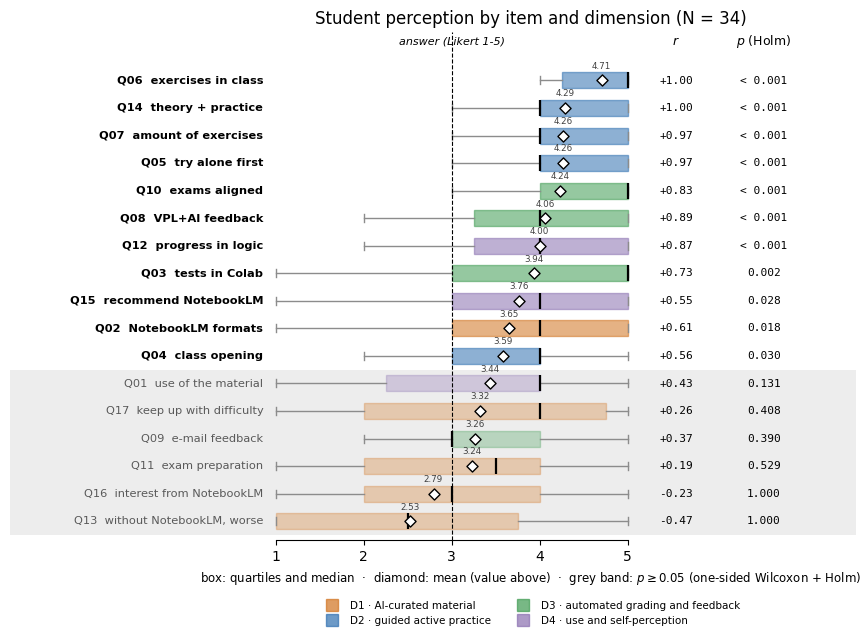

In [13]:
COL = {"D1": "#d1731f", "D2": "#2f6fb0", "D3": "#3f9b52", "D4": "#8a6fb0"}
LAB = {"D1": "D1 · AI-curated material", "D2": "D2 · guided active practice",
       "D3": "D3 · automated grading and feedback", "D4": "D4 · use and self-perception"}
order = list(pa[SUBST].mean().sort_values(ascending=False).index)
fig, ax = plt.subplots(figsize=(8.4, 6.6))
trans = blended_transform_factory(ax.transAxes, ax.transData)
for i, q in enumerate(order):
    y = len(order) - 1 - i
    x = pa[q].to_numpy(float)
    ns = not it.loc[q, "sig"]
    if ns:
        ax.add_patch(plt.Rectangle((-0.30, y - 0.5), 1.30, 1.0, transform=trans,
                                   facecolor="0.93", edgecolor="none", zorder=0, clip_on=False))
    bp = ax.boxplot(x, positions=[y], vert=False, widths=0.58, patch_artist=True,
                    showfliers=False, medianprops=dict(color="black", lw=1.6),
                    whiskerprops=dict(color="0.55"), capprops=dict(color="0.55"))
    bp["boxes"][0].set(facecolor=COL[DIM_OF[q]], alpha=0.30 if ns else 0.55,
                       edgecolor=COL[DIM_OF[q]])
    ax.scatter(x.mean(), y, marker="D", s=32, color="white", edgecolor="black", zorder=4)
    ax.annotate(f"{x.mean():.2f}", (x.mean(), y), textcoords="offset points", xytext=(0, 7),
                ha="center", va="bottom", fontsize=6.3, color="0.25", zorder=5)
    ax.text(0.86, y, f"{q}  {MNEM[q]}", ha="right", va="center", fontsize=8.2,
            fontweight="normal" if ns else "bold", color="0.35" if ns else "black")
    ax.text(5.55, y, f"{it.loc[q, 'r']:+.2f}", ha="center", va="center", fontsize=8,
            family="monospace")
    p_ = it.loc[q, "p_holm"]
    ax.text(6.55, y, "< 0.001" if p_ < .001 else f"{p_:.3f}", ha="center", va="center",
            fontsize=8, family="monospace")
top = len(order) - 0.25
ax.text(3, top + 0.55, "answer (Likert 1-5)", ha="center", fontsize=8, style="italic")
ax.text(5.55, top + 0.55, "$r$", ha="center", fontsize=9)
ax.text(6.55, top + 0.55, "$p$ (Holm)", ha="center", fontsize=9)
ax.axvline(3, color="k", ls="--", lw=0.8)
ax.set_yticks([]); ax.set_ylim(-0.7, top + 1.0); ax.set_xlim(0.2, 7.6); ax.set_xticks(range(1, 6))
ax.set_xlabel("box: quartiles and median  ·  diamond: mean (value above)  ·  "
              "grey band: $p \\geq 0.05$ (one-sided Wilcoxon + Holm)", fontsize=8.5)
ax.set_title(f"Student perception by item and dimension (N = {N})")
ax.spines["bottom"].set_bounds(1, 5)
ax.legend(handles=[plt.Line2D([], [], marker="s", ls="", ms=9, color=COL[d], alpha=0.7,
                              label=LAB[d]) for d in DIMS],
          loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, fontsize=7.5, frameon=False)
for s in ("top", "right", "left"):
    ax.spines[s].set_visible(False)
plt.show()

---
# Part 4 — RQ2: roles of AI compared within subjects

RQ2 compares, within the same students, the three items that name a role
of AI and ask whether it helped: **Q02** (AI-generated material), **Q08**
(AI feedback attached to each VPL submission) and **Q09** (AI feedback
e-mailed after the exams). Friedman's test (Friedman, 1937) with Kendall's
W (Kendall & Babington Smith, 1939), then the three pairs by two-sided
Wilcoxon signed-rank tests with Holm correction; r is the rank-biserial
correlation of the paired differences. (Until the v02 submission, RQ2
compared dimension scores; that comparison was dropped because the items
of the dimensions are not parallel in wording.)

📄 *In the manuscript:* Section "Roles of AI compared within subjects (RQ2)"
and Table `tab:contrastes`.

In [14]:
ROLES = ["Q02", "Q08", "Q09"]
fr = stats.friedmanchisquare(*[pa[q] for q in ROLES])
W = fr.statistic / (N * (len(ROLES) - 1))
print(f"Friedman chi2(2) = {fr.statistic:.2f}, p = {fr.pvalue:.3g}, Kendall W = {W:.2f}")
check("Friedman chi2", fr.statistic, 11.8, 0.05)
check("Friedman p", fr.pvalue, 0.003, 0.0005)
check("Kendall W", W, 0.17, 0.005)

pairs = []
for a, b in [("Q08", "Q09"), ("Q08", "Q02"), ("Q02", "Q09")]:
    diff = (pa[a] - pa[b]).to_numpy()
    w = stats.wilcoxon(pa[a], pa[b], alternative="two-sided")
    pairs.append(dict(pair=f"{a}-{b}", median_diff=np.median(diff), r=rank_biserial(diff, 0),
                      higher=int((diff > 0).sum()), same=int((diff == 0).sum()),
                      lower=int((diff < 0).sum()), p=w.pvalue))
pairs = pd.DataFrame(pairs)
pairs["p_holm"] = multipletests(pairs.p, method="holm")[1]
display(pairs.round(3))
P = pairs.set_index("pair")
for pair, md_, r_, ph, hsl in [("Q08-Q09", 1.0, .71, .005, (20, 10, 4)),
                               ("Q08-Q02", 0.5, .35, .24, (17, 10, 7)),
                               ("Q02-Q09", 0.0, .37, .24, (14, 12, 8))]:
    check(f"{pair} median diff", P.loc[pair, "median_diff"], md_, 0.005)
    check(f"{pair} r", P.loc[pair, "r"], r_, 0.005)
    check(f"{pair} p_holm", P.loc[pair, "p_holm"], ph, 0.005)
    check(f"{pair} higher/same/lower", tuple(P.loc[pair, ["higher", "same", "lower"]]) == hsl, 1, 0)
mean_ = pa[ROLES].mean()
for q, m in [("Q02", 3.65), ("Q08", 4.06), ("Q09", 3.26)]:
    check(f"{q} mean", mean_[q], m, 0.005)

Friedman chi2(2) = 11.76, p = 0.00279, Kendall W = 0.17
  [OK] Friedman chi2: computed=11.76  manuscript=11.8
  [OK] Friedman p: computed=0.002795  manuscript=0.003
  [OK] Kendall W: computed=0.1729  manuscript=0.17


,pair,median_diff,r,higher,same,lower,p,p_holm
0,Q08-Q09,1.0,0.707,20,10,4,0.002,0.005
1,Q08-Q02,0.5,0.350,17,10,7,0.126,0.237
2,Q02-Q09,0.0,0.368,14,12,8,0.119,0.237


  [OK] Q08-Q09 median diff: computed=1  manuscript=1.0
  [OK] Q08-Q09 r: computed=0.7067  manuscript=0.71
  [OK] Q08-Q09 p_holm: computed=0.005036  manuscript=0.005
  [OK] Q08-Q09 higher/same/lower: computed=1  manuscript=1
  [OK] Q08-Q02 median diff: computed=0.5  manuscript=0.5
  [OK] Q08-Q02 r: computed=0.35  manuscript=0.35
  [OK] Q08-Q02 p_holm: computed=0.2371  manuscript=0.24
  [OK] Q08-Q02 higher/same/lower: computed=1  manuscript=1
  [OK] Q02-Q09 median diff: computed=0  manuscript=0.0
  [OK] Q02-Q09 r: computed=0.3676  manuscript=0.37
  [OK] Q02-Q09 p_holm: computed=0.2371  manuscript=0.24
  [OK] Q02-Q09 higher/same/lower: computed=1  manuscript=1
  [OK] Q02 mean: computed=3.647  manuscript=3.65
  [OK] Q08 mean: computed=4.059  manuscript=4.06
  [OK] Q09 mean: computed=3.265  manuscript=3.26


---
# Part 5 — RQ3: exam grades proposed by an LLM

After each exam, the submitted code was also graded by an LLM against a
rubric. In Exam 3 (34 students) the DeepSeek grading was run five times
(run 5 is the one sent to students) and once with Gemini 2.5 Flash. The
**final grade** is the instructor's, assigned with the LLM proposal in view,
so it is not an independent reference.

Agreement is measured by **ICC(2,1)** — two-way random effects, absolute
agreement, single measure (Shrout & Fleiss, 1979) — by the **mean absolute
difference (MAD)** and by the **bias** (mean signed difference, source −
reference), in points on the 0–100 exam scale.

📄 *In the manuscript:* Section "Nota de prova proposta por LLM (QP3)" and
Table `tab:llm`.

In [15]:
def icc21(X):
    X = np.asarray(X, float)
    n_, k_ = X.shape
    m = X.mean()
    msr = k_ * ((X.mean(1) - m) ** 2).sum() / (n_ - 1)
    msc = n_ * ((X.mean(0) - m) ** 2).sum() / (k_ - 1)
    mse = ((X - X.mean(1, keepdims=True) - X.mean(0) + m) ** 2).sum() / ((n_ - 1) * (k_ - 1))
    return (msr - mse) / (msr + (k_ - 1) * mse + k_ * (msc - mse) / n_)

def agree(source, reference):
    x = exams[[reference, source]].dropna()
    d = x[source] - x[reference]
    return dict(n=len(x), ICC=icc21(x), MAD=d.abs().mean(), bias=d.mean())

runs = [f"p3_deepseek_run{i}" for i in range(1, 6)]
x5 = exams[runs].dropna()
print(f"Exam 3: {len(x5)} students with the five DeepSeek runs")
check("Exam 3 students", len(x5), 34, 0)
check("ICC across the five DeepSeek runs", icc21(x5), 0.97, 0.005)

rows = {
    "P3 Gemini vs DeepSeek (sent)": agree("p3_gemini", "p3_deepseek_run5"),
    "P3 DeepSeek (sent) vs VPL": agree("p3_deepseek_run5", "p3_vpl"),
    "P3 DeepSeek (sent) vs final": agree("p3_deepseek_run5", "p3_final"),
    "P3 VPL vs final": agree("p3_vpl", "p3_final"),
    "P2 DeepSeek vs final": agree("p2_deepseek", "p2_final"),
    "P2 VPL vs final": agree("p2_vpl", "p2_final"),
}
tab_llm = pd.DataFrame(rows).T
display(tab_llm.round(2))

for key, (icc, mad, bias) in {
        "P3 Gemini vs DeepSeek (sent)": (.90, 8.4, -6.2),
        "P3 DeepSeek (sent) vs VPL": (.63, 20.2, 14.9),
        "P3 DeepSeek (sent) vs final": (.89, 7.7, -2.3),
        "P3 VPL vs final": (.64, 20.1, -17.2),
        "P2 DeepSeek vs final": (.92, 10.0, 1.2),
        "P2 VPL vs final": (.94, 10.5, -9.6)}.items():
    check(f"{key}: ICC", tab_llm.loc[key, "ICC"], icc, 0.005)
    check(f"{key}: MAD", tab_llm.loc[key, "MAD"], mad, 0.05)
    check(f"{key}: bias", tab_llm.loc[key, "bias"], bias, 0.05)
check("Exam 2 students", tab_llm.loc["P2 VPL vs final", "n"], 37, 0)

Exam 3: 34 students with the five DeepSeek runs
  [OK] Exam 3 students: computed=34  manuscript=34
  [OK] ICC across the five DeepSeek runs: computed=0.9704  manuscript=0.97


,n,ICC,MAD,bias
P3 Gemini vs DeepSeek (sent),34.0,0.90,8.35,-6.24
P3 DeepSeek (sent) vs VPL,34.0,0.63,20.24,14.94
P3 DeepSeek (sent) vs final,34.0,0.89,7.68,-2.26
P3 VPL vs final,34.0,0.64,20.15,-17.21
P2 DeepSeek vs final,37.0,0.92,10.00,1.19
P2 VPL vs final,37.0,0.94,10.50,-9.60


  [OK] P3 Gemini vs DeepSeek (sent): ICC: computed=0.8965  manuscript=0.9
  [OK] P3 Gemini vs DeepSeek (sent): MAD: computed=8.353  manuscript=8.4
  [OK] P3 Gemini vs DeepSeek (sent): bias: computed=-6.235  manuscript=-6.2
  [OK] P3 DeepSeek (sent) vs VPL: ICC: computed=0.6272  manuscript=0.63
  [OK] P3 DeepSeek (sent) vs VPL: MAD: computed=20.24  manuscript=20.2
  [OK] P3 DeepSeek (sent) vs VPL: bias: computed=14.94  manuscript=14.9
  [OK] P3 DeepSeek (sent) vs final: ICC: computed=0.89  manuscript=0.89
  [OK] P3 DeepSeek (sent) vs final: MAD: computed=7.676  manuscript=7.7
  [OK] P3 DeepSeek (sent) vs final: bias: computed=-2.265  manuscript=-2.3
  [OK] P3 VPL vs final: ICC: computed=0.6432  manuscript=0.64
  [OK] P3 VPL vs final: MAD: computed=20.15  manuscript=20.1
  [OK] P3 VPL vs final: bias: computed=-17.21  manuscript=-17.2
  [OK] P2 DeepSeek vs final: ICC: computed=0.9217  manuscript=0.92
  [OK] P2 DeepSeek vs final: MAD: computed=10  manuscript=10.0
  [OK] P2 DeepSeek vs fina

**How close the final grade is to the LLM by construction.** Run 1 was made
right after the exam, and the instructor reviewed the grades starting from
it; runs 2-5 came in the next two days (run 5 was e-mailed to students, with
the grade already published). The final grade is identical to run 1 far more
often than to the later runs.

In [16]:
x = exams[["p3_final", "p3_deepseek_run1"]].dropna()
same = int((x.p3_final == x.p3_deepseek_run1).sum())
print(f"final grade identical to run 1 in {same}/{len(x)} cases")
check("final == DeepSeek run 1", same, 16, 0)
r1 = agree("p3_deepseek_run1", "p3_final")
check("run 1 vs final: ICC", r1["ICC"], 0.92, 0.005)
check("run 1 vs final: MAD", r1["MAD"], 5.4, 0.05)
check("run 1 vs final: bias", r1["bias"], -2.2, 0.05)
check("final differs from run 1 (review changed the proposal)", len(x) - same, 18, 0)
later = [int((exams.p3_final == exams[f"p3_deepseek_run{i}"]).sum()) for i in range(2, 6)]
print("final identical to runs 2-5:", later)
check("runs 2-5: fewest identical", min(later), 10, 0)
check("runs 2-5: most identical", max(later), 12, 0)

final grade identical to run 1 in 16/34 cases
  [OK] final == DeepSeek run 1: computed=16  manuscript=16
  [OK] run 1 vs final: ICC: computed=0.9154  manuscript=0.92
  [OK] run 1 vs final: MAD: computed=5.353  manuscript=5.4
  [OK] run 1 vs final: bias: computed=-2.235  manuscript=-2.2
  [OK] final differs from run 1 (review changed the proposal): computed=18  manuscript=18
final identical to runs 2-5: [10, 12, 11, 10]
  [OK] runs 2-5: fewest identical: computed=10  manuscript=10
  [OK] runs 2-5: most identical: computed=12  manuscript=12


**Provider change and effect on the official grade.** In Exam 1 the tool
(Groq, free plan) tried a fixed list of models in order and moved to the
next when one failed (e.g. at the rate limit), so two models ended up
grading the exam; from Exam 2 on, one model (DeepSeek) graded the whole
class. In every exam the official grade is the instructor's, reviewed from
the automatic VPL grade (`p*_vpl`, proportional to the test cases passed)
with the LLM proposal in view. In Exam 1 the review was made inside the VPL
(`p1_vpl_reviewed`); two grades went down for use of forbidden built-ins.

In [17]:
m1 = pd.read_csv(DATA / "exam1_llm_models.csv").set_index("model").questions_graded
print(m1.to_dict())
check("Exam 1: questions graded", m1.sum(), 76, 0)
check("Exam 1: by gpt-oss-120b", m1["openai/gpt-oss-120b"], 74, 0)
check("Exam 1: by Llama 3.3", m1["llama-3.3-70b-versatile"], 2, 0)
x = exams[["p1_vpl", "p1_final"]].dropna()
check("Exam 1: students", len(x), 40, 0)
print("Exam 1: final kept / raised / lowered the automatic VPL grade:",
      int((x.p1_final == x.p1_vpl).sum()), int((x.p1_final > x.p1_vpl).sum()),
      int((x.p1_final < x.p1_vpl).sum()))
check("Exam 1: review lowered the VPL grade", int((x.p1_final < x.p1_vpl).sum()), 2, 0)
lowered = sum(int((exams[f"{p}_final"] < exams[f"{p}_vpl"]).sum()) for p in ("p1", "p2", "p3"))
graded = sum(len(exams[[f"{p}_final", f"{p}_vpl"]].dropna()) for p in ("p1", "p2", "p3"))
check("Exams 1-3: graded students x exams", graded, 111, 0)
check("Exams 1-3: review lowered the VPL grade", lowered, 5, 0)
check("Exams 1-3: kept or raised", graded - lowered, 106, 0)

{'llama-3.3-70b-versatile': 2, 'openai/gpt-oss-120b': 74}
  [OK] Exam 1: questions graded: computed=76  manuscript=76
  [OK] Exam 1: by gpt-oss-120b: computed=74  manuscript=74
  [OK] Exam 1: by Llama 3.3: computed=2  manuscript=2
  [OK] Exam 1: students: computed=40  manuscript=40
Exam 1: final kept / raised / lowered the automatic VPL grade: 24 14 2
  [OK] Exam 1: review lowered the VPL grade: computed=2  manuscript=2
  [OK] Exams 1-3: graded students x exams: computed=111  manuscript=111
  [OK] Exams 1-3: review lowered the VPL grade: computed=5  manuscript=5
  [OK] Exams 1-3: kept or raised: computed=106  manuscript=106


**The example of an LLM-proposed grade** (table `tab:llm_exemplo`). The
file `exam3/example_llm_output.txt` is one output of the run sent to
students; `exam3/prompt_exam3.txt` holds the rubric weights. In Criterion 2,
three sub-items judged correct are worth 5, 10 and 10 points in the rubric
but received 5 each (Discussion, "Estabilidade da nota proposta por LLM").

In [18]:
import re
out = (EXAM3 / "example_llm_output.txt").read_text(encoding="utf-8")
got = [tuple(map(int, m)) for m in re.findall(r"Critério \d - \[(\d+)/(\d+) pts\]", out)]
print("criteria (proposed, max):", got)
for (g, mx), (eg, emx) in zip(got, [(5, 10), (15, 25), (5, 15)]):
    check(f"criterion max {emx}: proposed", g, eg, 0)
    check(f"criterion max {emx}: max", mx, emx, 0)
check("total proposed", int(re.search(r"NOTA FINAL: (\d+)/50", out).group(1)), 25, 0)
rubric_b = (EXAM3 / "prompt_exam3.txt").read_text(encoding="utf-8").split("[START_RUBRICA_B]")[1]
crit2 = rubric_b.split("Critério 2")[1].split("Critério 3")[0]
weights = [int(w) for w in re.findall(r"\((\d+) pts\)", crit2)]
print("rubric B, criterion 2 sub-item weights:", weights)
check("sub-item weights 5, 10, 10", weights == [5, 10, 10], 1, 0)

criteria (proposed, max): [(5, 10), (15, 25), (5, 15)]
  [OK] criterion max 10: proposed: computed=5  manuscript=5
  [OK] criterion max 10: max: computed=10  manuscript=10
  [OK] criterion max 25: proposed: computed=15  manuscript=15
  [OK] criterion max 25: max: computed=25  manuscript=25
  [OK] criterion max 15: proposed: computed=5  manuscript=5
  [OK] criterion max 15: max: computed=15  manuscript=15
  [OK] total proposed: computed=25  manuscript=25
rubric B, criterion 2 sub-item weights: [5, 10, 10]
  [OK] sub-item weights 5, 10, 10: computed=1  manuscript=1


**Cost.** The provider's usage export was downloaded right before and right
after runs 4 and 5; the cost of a run is the difference of the
month-to-date totals.

📄 *In the manuscript:* "US$ 0,025" for grading Exam 3 of the class.

In [19]:
u = usage.pivot_table(index=["run", "metric"], columns="snapshot", values="value")
cost = (u["after"] - u["before"]).unstack("metric")
display(cost[["cost_usd_month_to_date", "request_count", "output_tokens"]])
check("run 5 cost (US$)", cost.loc["5", "cost_usd_month_to_date"], 0.025, 0.0005)
check("run 5 requests", cost.loc["5", "request_count"], 65, 0)
inp5 = cost.loc["5", "input_cache_hit_tokens"] + cost.loc["5", "input_cache_miss_tokens"]
check("run 5 input tokens (thousands)", inp5 / 1000, 124, 0.5)
check("run 5 output tokens (thousands)", cost.loc["5", "output_tokens"] / 1000, 29, 0.5)
check("run 4 cost (US$)", cost.loc["4", "cost_usd_month_to_date"], 0.0244, 0.0005)

metric,cost_usd_month_to_date,request_count,output_tokens
run,,,
4,0.024365,69.0,31021.0
5,0.025009,65.0,29201.0


  [OK] run 5 cost (US$): computed=0.02501  manuscript=0.025
  [OK] run 5 requests: computed=65  manuscript=65
  [OK] run 5 input tokens (thousands): computed=124.4  manuscript=124
  [OK] run 5 output tokens (thousands): computed=29.2  manuscript=29
  [OK] run 4 cost (US$): computed=0.02437  manuscript=0.0244


---
# Part 6 — Mock exams

Three single-question mock exams preceded the exams; an empty cell means
the student did not take it.

📄 *In the manuscript:* Table `tab:decisoes` ("22 de 41 estudantes fizeram
os três simulados").

In [20]:
took_exam = exams[["p1_vpl", "p2_vpl", "p3_vpl"]].notna().any(axis=1)
n_mocks = exams[["mock1", "mock2", "mock3"]].notna().sum(axis=1)
check("students with at least one exam", took_exam.sum(), 41, 0)
check("took all three mock exams", (n_mocks[took_exam] == 3).sum(), 22, 0)
check("Exam 1: median VPL submissions per student", exams.p1_submissions.median(), 16.5, 0)

  [OK] students with at least one exam: computed=41  manuscript=41
  [OK] took all three mock exams: computed=22  manuscript=22
  [OK] Exam 1: median VPL submissions per student: computed=16.5  manuscript=16.5


---
# Part 7 — Same material, another outcome: the comparison classes

Two evening classes of Campus 2 used the material of Layers 1–3 with their
own assessment design (two fixed-question exams; exercises formative only).

📄 *In the manuscript:* Section "Mesmo material, outro desfecho".

In [21]:
cc = series[series.class_label.isin(["C1", "C2"])].set_index("class_label")
for c, rate, kk, nn in [("C1", 81.6, 31, 38), ("C2", 85.0, 34, 40)]:
    check(f"{c} failures", cc.loc[c, "n_failed"], kk, 0)
    check(f"{c} assessed", cc.loc[c, "n_assessed"], nn, 0)
    check(f"{c} failure rate (%)", 100 * cc.loc[c, "rate"], rate, 0.05)

c2hist = series[(series.campus == "2") & (series["shift"] == "evening")
                & (series.on_schedule_term == 1) & (series.year < 2026)]
check("Campus 2 evening, on-schedule 2009-2025: classes", len(c2hist), 56, 0)
check("... pooled failure (%)", pct(c2hist.n_failed.sum(), c2hist.n_assessed.sum()), 34.4, 0.05)

  [OK] C1 failures: computed=31  manuscript=31
  [OK] C1 assessed: computed=38  manuscript=38
  [OK] C1 failure rate (%): computed=81.58  manuscript=81.6
  [OK] C2 failures: computed=34  manuscript=34
  [OK] C2 assessed: computed=40  manuscript=40
  [OK] C2 failure rate (%): computed=85  manuscript=85.0
  [OK] Campus 2 evening, on-schedule 2009-2025: classes: computed=56  manuscript=56
  [OK] ... pooled failure (%): computed=34.42  manuscript=34.4


**Perception in the comparison classes.** Item by item, the analysed class
(N = 34) and the comparison classes (N = 40) are compared by the
Mann–Whitney U test (Mann & Whitney, 1947), two-sided, with Holm correction
over the 16 substantive items applicable to both (Q09, on e-mail feedback,
is left out: that feedback was not offered in the comparison classes). The
effect size is the rank-biserial correlation $r = 2U/(n_1 n_2) - 1$, positive
when the analysed class rates higher.
Since the v03 submission (2026-09-26) the manuscript reports this comparison
descriptively ("the largest difference was in Q07"); the test is kept here as
a supplementary check.

In [22]:
pc = perc[perc.group == "comparison"]
check("comparison respondents", len(pc), 40, 0)
ITEMS16 = [q for q in SUBST if q != "Q09"]
mw = []
for q in ITEMS16:
    u_ = stats.mannwhitneyu(pa[q], pc[q], alternative="two-sided")
    mw.append(dict(item=q, median_an=pa[q].median(), median_cmp=pc[q].median(),
                   r=2 * u_.statistic / (len(pa) * len(pc)) - 1, p=u_.pvalue))
mw = pd.DataFrame(mw)
mw["p_holm"] = multipletests(mw.p, method="holm")[1]
display(mw.round(3))
check("items differing after Holm", (mw.p_holm < .05).sum(), 1, 0)
q07 = mw.set_index("item").loc["Q07"]
check("the item is Q07", q07.p_holm < .05, 1, 0)
check("Q07 r", q07.r, 0.39, 0.005)
check("Q07 p_holm", q07.p_holm, 0.046, 0.0005)

  [OK] comparison respondents: computed=40  manuscript=40


,item,median_an,median_cmp,r,p,p_holm
0,Q01,4.0,4.0,-0.099,0.456,1.000
1,Q02,4.0,4.0,-0.035,0.792,1.000
2,Q03,5.0,4.0,-0.001,0.995,1.000
3,Q04,4.0,4.0,-0.097,0.461,1.000
4,Q05,4.0,4.0,0.179,0.163,1.000
5,Q06,5.0,4.0,0.337,0.005,0.071
6,Q07,4.0,4.0,0.385,0.003,0.046
7,Q08,4.0,4.0,0.128,0.325,1.000
8,Q10,5.0,4.0,0.141,0.266,1.000
9,Q11,3.5,4.0,-0.165,0.212,1.000


  [OK] items differing after Holm: computed=1  manuscript=1
  [OK] the item is Q07: computed=1  manuscript=1
  [OK] Q07 r: computed=0.3853  manuscript=0.39
  [OK] Q07 p_holm: computed=0.04602  manuscript=0.046


**Shift alone does not explain the outcome.** Evening classes of Campus 1,
on-schedule term, 2009–2025: range of failure rates and how many were at or
below 21%.

In [23]:
ev1 = series[(series.campus == "1") & (series["shift"] == "evening")
             & (series.on_schedule_term == 1) & (series.year < 2026)]
check("classes", len(ev1), 223, 0)
check("lowest failure (%)", 100 * ev1.rate.min(), 0, 0.05)
check("highest failure (%)", 100 * ev1.rate.max(), 87.5, 0.05)
check("classes at or below 21%", (ev1.rate <= 0.21).sum(), 67, 0)

  [OK] classes: computed=223  manuscript=223
  [OK] lowest failure (%): computed=0  manuscript=0
  [OK] highest failure (%): computed=87.5  manuscript=87.5
  [OK] classes at or below 21%: computed=67  manuscript=67


---
All `check(...)` calls above passed: every number printed in the manuscript
is reproduced from the de-identified data in `data/`.

**References for the methods.** Cohen (1988), *Statistical Power Analysis
for the Behavioral Sciences*; Cronbach (1951), *Psychometrika* 16:297–334;
Efron & Tibshirani (1993), *An Introduction to the Bootstrap*; Fisher (1922),
*J. R. Stat. Soc.* 85:87–94; Friedman (1937), *JASA* 32:675–701; Holm (1979),
*Scand. J. Stat.* 6:65–70; Kendall & Babington Smith (1939), *Ann. Math.
Stat.* 10:275–287; Kerby (2014), *Comprehensive Psychology* 3; Mann &
Whitney (1947), *Ann. Math. Stat.* 18:50–60; Shapiro & Wilk (1965),
*Biometrika* 52:591–611; Shrout & Fleiss (1979), *Psychol. Bull.*
86:420–428; Wilcoxon (1945), *Biometrics Bull.* 1:80–83; Wilson (1927),
*JASA* 22:209–212.